In [1]:
# BUSINESS PERFORMANCE & PROFITABILITY ANALYSIS OF SUPERSTORE SALES

In [2]:
# Project Overview
# This project analyzes retail sales transaction data to uncover revenue trends, seasonal demand patterns, and category-level profitability.

In [3]:
# Objective

#Understand sales distribution

#Identify high-performing categories and regions

#Analyze seasonal patterns

#Evaluate profit predictability using Linear Regression

In [4]:
# Tools Used

#Python
#Pandas
#Matplotlib
#Seaborn
#Scikit-learn
#Statsmodels

In [5]:
#1. Data Loading

In [6]:
import pandas as pd

In [7]:
SS_Sales= pd.read_csv(r"C:\Users\Avni\OneDrive\Desktop\Superstores Sales Data.csv")
SS_Sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21-05-2017,28-05-2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12-01-2016,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12-01-2016,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12-01-2016,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [8]:
# 2. Data Cleaning & Preparation

In [9]:
SS_Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [10]:
SS_Sales['Order Date']=pd.to_datetime(SS_Sales['Order Date'],dayfirst=True)
SS_Sales['Ship Date']=pd.to_datetime(SS_Sales['Ship Date'],dayfirst=True)
SS_Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [11]:
SS_Sales.describe

<bound method NDFrame.describe of       Row ID        Order ID Order Date  Ship Date       Ship Mode  \
0          1  CA-2017-152156 2017-11-08 2017-11-11    Second Class   
1          2  CA-2017-152156 2017-11-08 2017-11-11    Second Class   
2          3  CA-2017-138688 2017-06-12 2017-06-16    Second Class   
3          4  US-2016-108966 2016-10-11 2016-10-18  Standard Class   
4          5  US-2016-108966 2016-10-11 2016-10-18  Standard Class   
...      ...             ...        ...        ...             ...   
9795    9796  CA-2017-125920 2017-05-21 2017-05-28  Standard Class   
9796    9797  CA-2016-128608 2016-01-12 2016-01-17  Standard Class   
9797    9798  CA-2016-128608 2016-01-12 2016-01-17  Standard Class   
9798    9799  CA-2016-128608 2016-01-12 2016-01-17  Standard Class   
9799    9800  CA-2016-128608 2016-01-12 2016-01-17  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consume

In [12]:
SS_Sales.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [13]:
SS_Sales[SS_Sales["Postal Code"].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [15]:
SS_Sales['Postal Code']=SS_Sales['Postal Code'].fillna('05401', inplace=True)

In [16]:
SS_Sales['Postal Code'].isnull().sum()

np.int64(9800)

In [17]:
SS_Sales.shape

(9800, 18)

In [18]:
#3. Exploratory Data Analysis

In [19]:
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
%matplotlib inline

In [20]:
Total_Sales=SS_Sales['Sales'].sum()  
Total_Sales

np.float64(2261536.7827000003)

In [21]:
# 4. Sales Distribution Analysis

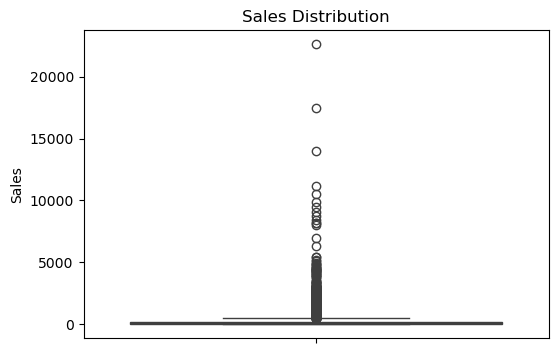

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(y=SS_Sales['Sales'])
plt.title('Sales Distribution')
plt.show()

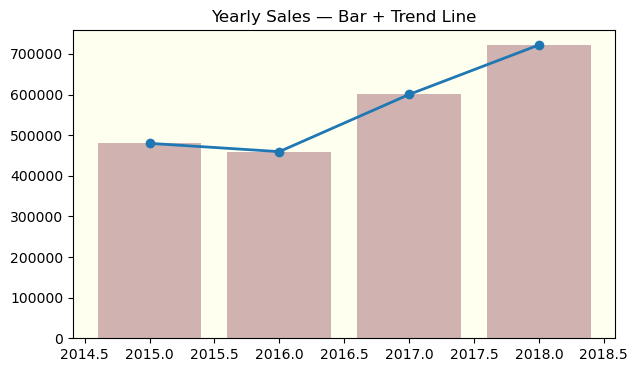

In [32]:
SS_Sales['Year']=SS_Sales['Order Date'].dt.year
Yearly_Sales = SS_Sales.groupby('Year')['Sales'].sum()
Yearly_Sales 
plt.figure(figsize=(7,4))
ax = plt.gca()
ax.set_facecolor('#FFFFF0') 
plt.bar(Yearly_Sales.index, Yearly_Sales.values, alpha=0.3,color = ['#650021'])

plt.plot(Yearly_Sales.index, Yearly_Sales.values, marker='o', linewidth=2)

plt.title('Yearly Sales — Bar + Trend Line')
plt.xlabel=('Year')
plt.ylabel=('Total Sales')

plt.show()

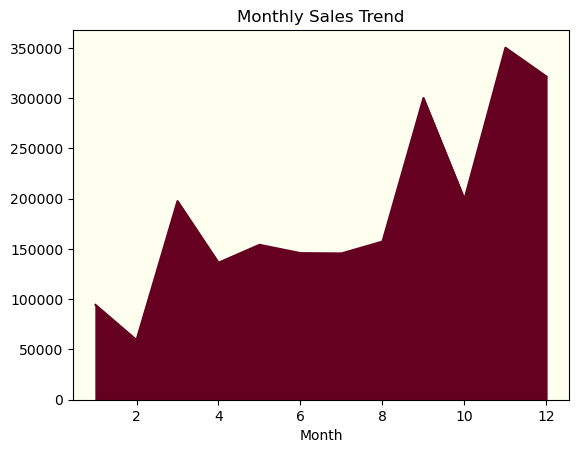

In [33]:
#Sales by month
SS_Sales['Month'] = SS_Sales['Order Date'].dt.month
Monthly_Sales = SS_Sales.groupby('Month')['Sales'].sum()
Monthly_Sales
ax=Monthly_Sales.plot(kind='area',color = ['#650021'])
ax.set_facecolor('#FFFFF0')
plt.title("Monthly Sales Trend")
plt.ylabel=("Sales")
plt.show()

In [34]:
# 5. Category & Regional Performance

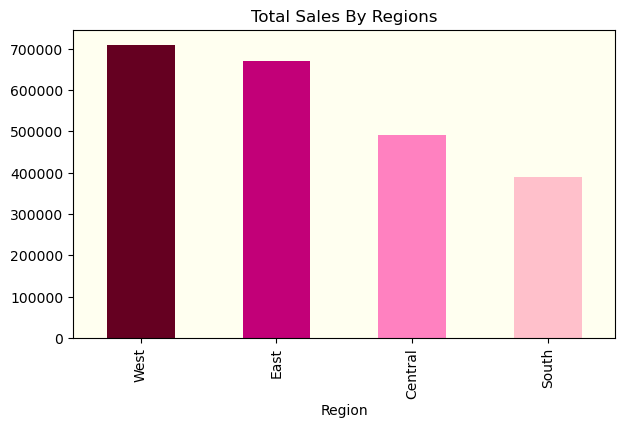

In [35]:
#Sales by Region
region_sales = SS_Sales.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales
plt.figure(facecolor='#FFFFFF',figsize=(7,4))
ax=region_sales.plot(kind='bar', color = ['#650021','#C20078','#FF81C0','#FFC0CB'])
ax.set_facecolor('#FFFFF0')
plt.title('Total Sales By Regions')
plt.xlabel=("Sales")
plt.ylabel=("Region")
plt.show()

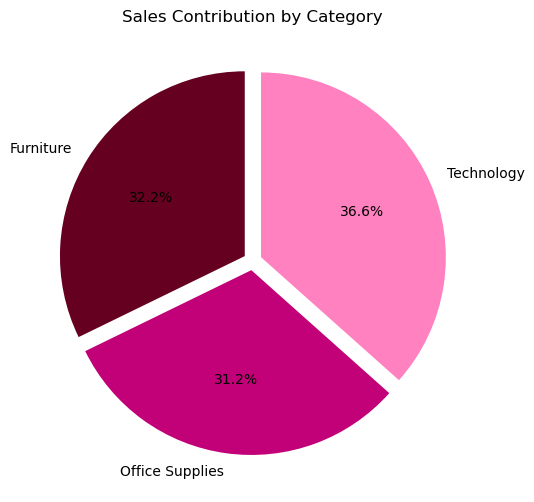

In [36]:
#Sales by category
Categorical_Sales = SS_Sales.groupby('Category')['Sales'].sum()
Categorical_Sales 
colors = ['#650021','#C20078','#FF81C0']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(6,6))

plt.pie(Categorical_Sales ,
        labels=Categorical_Sales.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode)

plt.title("Sales Contribution by Category")

plt.show()

In [37]:
# 6. Seasonal Trend Analysis

<Figure size 800x500 with 0 Axes>

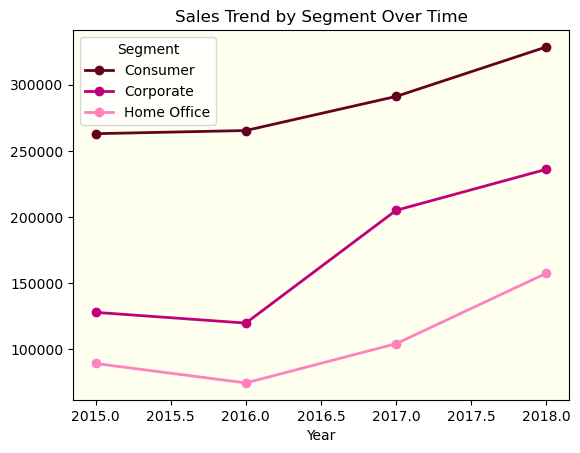

In [38]:
#Sales by Segment
SS_Sales['Year'] = SS_Sales['Order Date'].dt.year

segment_trend = SS_Sales.groupby(['Year','Segment'])['Sales'].sum().unstack()

plt.figure(figsize=(8,5))

ax = segment_trend.plot(marker='o', linewidth=2, color=['#650021','#C20078','#FF81C0'])
ax.set_facecolor('#FFFFF0')
plt.title("Sales Trend by Segment Over Time")
plt.xlabel=("Year")
plt.ylabel=("Sales")

plt.show()

In [40]:
#Profitablity(since there is no profit column I created an estimated column)

In [41]:
SS_Sales['Estimated Profit']=SS_Sales['Sales']*0.2
SS_Sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Estimated Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,None,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,52.3920
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,None,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,146.3880
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,None,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2.9240
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,None,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,191.5155
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,None,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4.4736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,...,None,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,2017,5,0.7596
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,None,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,2016,1,2.0736
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,None,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,2016,1,47.0376
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,None,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,2016,1,5.2752


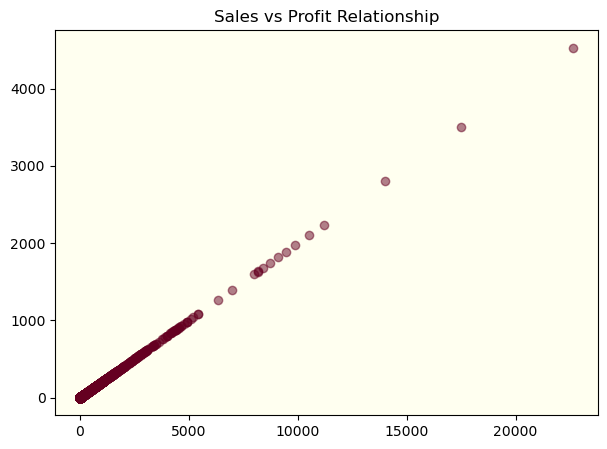

In [42]:
#Total Profit
Total_Profit = SS_Sales['Estimated Profit'].sum()
Total_Profit 
plt.figure(figsize=(7,5))
ax = plt.gca()
ax.set_facecolor('#FFFFF0') 
plt.scatter(SS_Sales['Sales'], SS_Sales['Estimated Profit'], alpha=0.5, color=['#650021'])

plt.title("Sales vs Profit Relationship")
plt.xlabel=("Sales")
plt.ylabel=("Estimated Profit")

plt.show()

In [43]:
SS_Sales.groupby('Category')[['Estimated Profit','Sales']].sum()

,Estimated Profit,Sales
Category,,
Furniture,145731.71514,728658.5757
Office Supplies,141084.46680,705422.3340
Technology,165491.17460,827455.8730


In [44]:
#Category performance varies across regions 

In [45]:
Performance_Comparison = SS_Sales.groupby(['Region','Category'])['Sales'].sum() 
Performance_Comparison

Region   Category       
Central  Furniture          160317.4622
         Office Supplies    163590.2430
         Technology         168739.2080
East     Furniture          206461.3880
         Office Supplies    199940.8110
         Technology         263116.5270
South    Furniture          116531.4800
         Office Supplies    124424.7710
         Technology         148195.2080
West     Furniture          245348.2455
         Office Supplies    217466.5090
         Technology         247404.9300
Name: Sales, dtype: float64

In [46]:
#Top Customers
SS_Sales.groupby('Customer Name')['Sales'].sum().nlargest(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

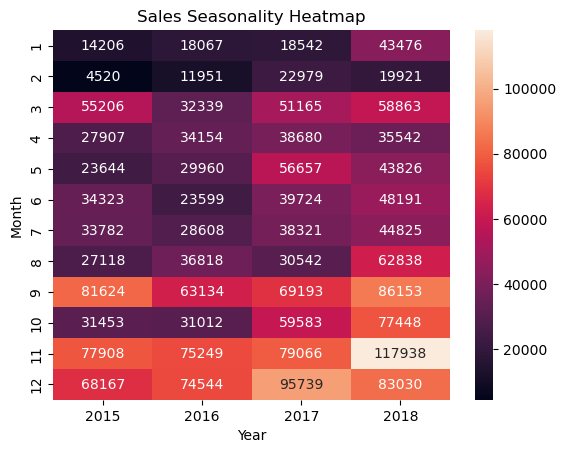

In [47]:
pivot = SS_Sales.pivot_table(values='Sales',
                       index='Month',
                       columns='Year',
                       aggfunc='sum')

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Sales Seasonality Heatmap")
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import multiprocessing

In [55]:
X = SS_Sales[['Sales']]
y = SS_Sales['Estimated Profit']

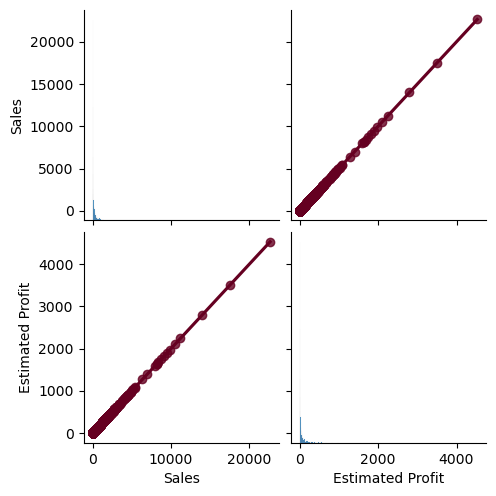

In [56]:
sns.pairplot(
    pair_data,
    kind='reg',
    plot_kws={'line_kws': {'color': '#650021'},
              'scatter_kws': {'color': '#650021'}}
)
plt.show()

In [60]:
# 8. Regression Modeling

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [79]:
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 1.0
MSE: 9.300549849326803e-27


In [ ]:
# 7. Correlation Analysis

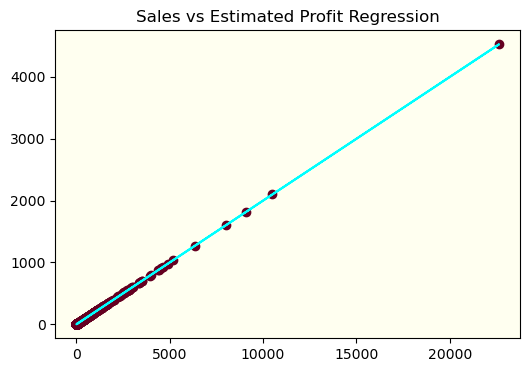

In [124]:
plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#FFFFF0')

plt.scatter(X_test, y_test,color=['#650021'])
plt.plot(X_test, y_pred,color='#00FFFF')
 

plt.title("Sales vs Estimated Profit Regression")
plt.xlabel=("Sales")
plt.ylabel=("Estimated Profit")

plt.show()

In [70]:
corr = SS_Sales[['Sales','Estimated Profit']].corr()
print(corr)

                  Sales  Estimated Profit
Sales               1.0               1.0
Estimated Profit    1.0               1.0


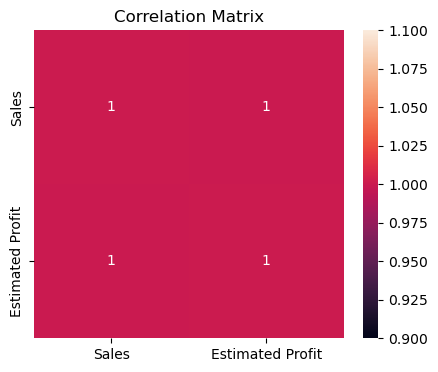

In [82]:
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# 9. Business Insights & Conclusion

In [80]:
X = sm.add_constant(X)
model_sm = sm.OLS(y, X).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:       Estimated Profit   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.662e+34
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:10:40   Log-Likelihood:             2.8213e+05
No. Observations:                9800   AIC:                        -5.643e+05
Df Residuals:                    9798   BIC:                        -5.642e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.882e-16   8.19e-16      1.085      0.2

In [ ]:
##The perfect correlation confirms a deterministic relationship between Sales and Estimated Profit.
##In real-world scenarios, additional explanatory variables would be required for robust forecasting.

In [ ]:
##Limitations

#Estimated Profit was derived from Sales, limiting predictive realism.
#No external economic or operational variables included.
#Analysis is limited to historical transaction data.